In [ ]:
## E-Commerce Recommendation System

## Business Problem

#Modern e-commerce platforms contain thousands of products.
#Users rarely browse the entire catalog.

#Recommendation systems help customers discover relevant products
#based on their behavior and preferences.

#Examples:
# Amazon
# Netflix
# YouTube
# Spotify

## Project Objective

#Build a user-based collaborative filtering recommendation system using implicit feedback data.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving interactions.csv to interactions.csv


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('interactions.csv')

In [3]:
df.head()

,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms
0,2ece1c7b-3244-4eeb-8d3e-f1b0cc09f20f,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,d3701c21-709a-4090-bab2-020261ce8a92,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:29:18.000000832,30481
1,bef097f8-4624-406a-9168-fc16f6d9db7a,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,d3701c21-709a-4090-bab2-020261ce8a92,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:29:50.726785665,37889
2,131590fb-aded-4eb2-b04a-158540271950,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,b1a8533d-7d06-48ae-b1d2-02a39ad1c623,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:30:37.244865920,11801
3,dda794be-afc4-4b8c-9a5c-3594d513f261,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,b1a8533d-7d06-48ae-b1d2-02a39ad1c623,0003375f-8f69-44e1-9429-ec083de18495,view,2025-03-13 08:30:37.244865920,11801
4,b68f3af4-29d1-4d85-884a-5e585d5d0a4a,8a49a58e-7e31-4616-8ac8-b1472ed4f5d8,2ee058a5-f098-4961-a46d-ba699b635b84,0003375f-8f69-44e1-9429-ec083de18495,add_to_wishlist,2025-03-13 08:30:50.152312822,1404


In [4]:
df.describe(include="all")

,interaction_id,user_id,product_id,session_id,interaction_type,timestamp,dwell_time_ms
count,100000,100000,100000,100000,100000,100000,100000.000000
unique,100000,6944,967,19315,6,96257,NaN
top,ffebb78d-b238-402e-924f-61b780361c67,2603c13e-2c0e-4098-9656-0da109a9dbfb,6e9b539a-77ad-4307-acb5-f558f8b5cc6f,8cf87e9e-9b56-482e-918c-bacf72c93677,view,2025-01-19 21:03:15.446884149,NaN
freq,1,88,6777,28,50463,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,17942.900550
std,NaN,NaN,NaN,NaN,NaN,NaN,21556.684456
min,NaN,NaN,NaN,NaN,NaN,NaN,500.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,4260.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,11153.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,23342.250000


In [5]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

,0
interaction_id,0
user_id,0
product_id,0
session_id,0
interaction_type,0
timestamp,0
dwell_time_ms,0


In [6]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [7]:
print(
    "Unique Users:",
    df["user_id"].nunique()
)

Unique Users: 6944


In [8]:
print(
    "Unique Products:",
    df["product_id"].nunique()
)

Unique Products: 967


In [9]:
interaction_counts = (
    df["interaction_type"]
    .value_counts()
)

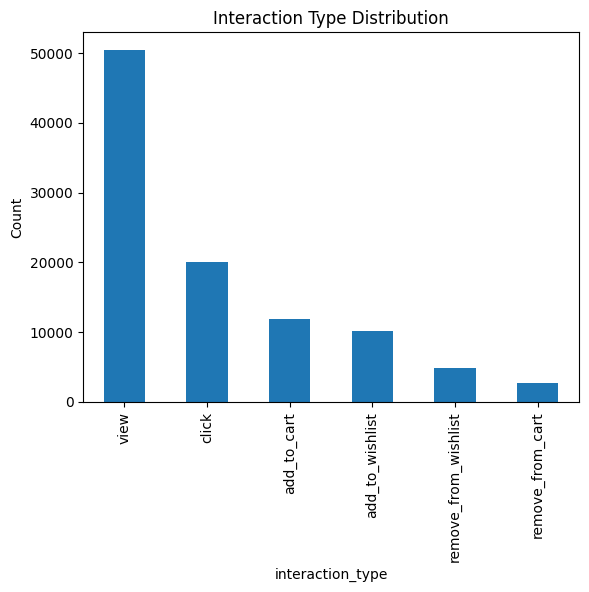

In [15]:
interaction_counts.plot(
    kind="bar"
)

plt.title("Interaction Type Distribution")
plt.ylabel("Count")
plt.show()

In [16]:
top_products = (
    df["product_id"]
    .value_counts()
    .head(20)
)

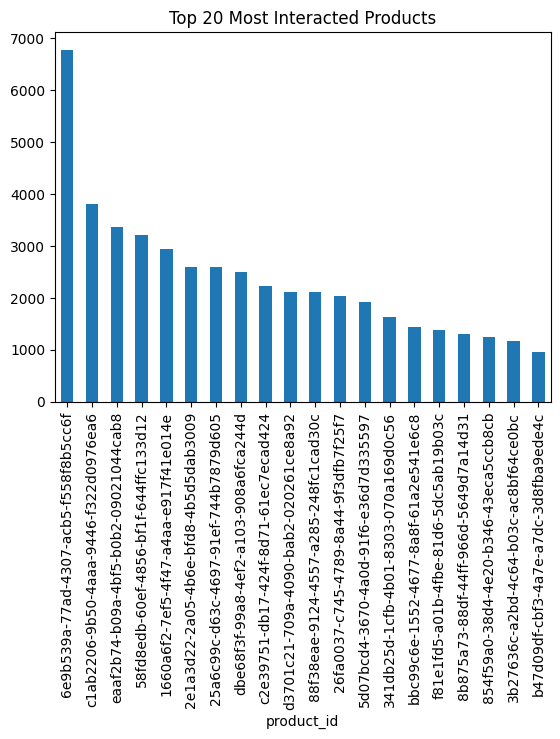

In [17]:
top_products.plot(kind="bar")
plt.title("Top 20 Most Interacted Products")
plt.show()

In [18]:
top_users = (
    df["user_id"]
    .value_counts()
    .head(20)
)

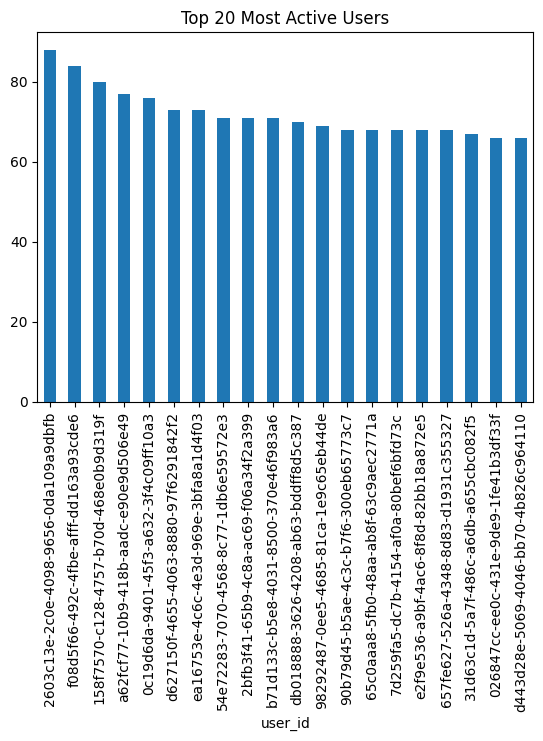

In [19]:
top_users.plot(kind="bar")
plt.title("Top 20 Most Active Users")
plt.show()

In [20]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)

In [21]:
print(
    "Earliest interaction:",
    df["timestamp"].min()
)

Earliest interaction: 2023-01-04 00:12:23.000000964


In [22]:
print(
    "Latest interaction:",
    df["timestamp"].max()
)

Latest interaction: 2026-05-31 22:38:27.298660882


In [24]:
from google.colab import files

# Save the cleaned DataFrame to CSV in the current directory
df.to_csv("eda_checked.csv", index=False)

print("Dataset saved as eda_checked.csv in your Colab environment.")

# Download the file to your local machine
files.download("eda_checked.csv")


Dataset saved as eda_checked.csv in your Colab environment.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>